In [ ]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# **Loading of the datasets**

In [ ]:
ct1 = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/classified_ts_01.csv')
ct1.head(2)

,Date,Value
0,1980-01-31,102.483571
1,1980-02-29,99.208478


In [ ]:
ct2 = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/classified_ts_02.csv')
ct2.head(2)

,Date,Value
0,1980-01-31,54.630888
1,1980-02-29,59.747484


In [ ]:
ct3 = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/classified_ts_03.csv')
ct3.head(2)

,Date,Value
0,1980-01-31,53.891805
1,1980-02-29,54.526661


In [ ]:
ct4 = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/classified_ts_04.csv')
ct4.head(2)

,Date,Value
0,1980-01-31,51.426532
1,1980-02-29,61.042403


In [ ]:
ct5 = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/classified_ts_05.csv')
ct5.head(2)

,Date,Value
0,1980-01-31,80.921924
1,1980-02-29,91.396150


In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

ct1['Date'] = pd.to_datetime(ct1['Date'])
ct1 = ct1.set_index('Date')
ct1_decomp = seasonal_decompose(ct1, model='additive')

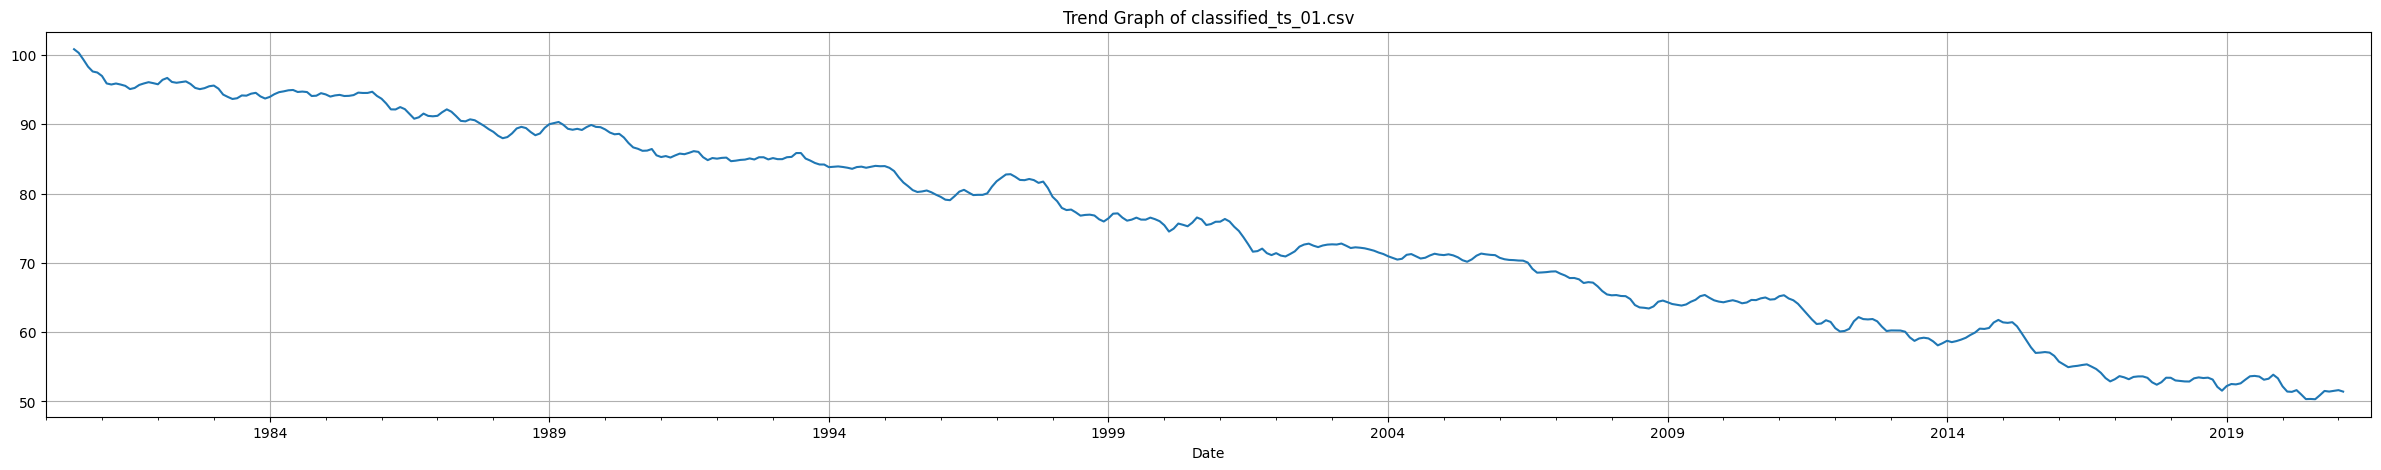

In [ ]:
# Question No. 1

ct1_decomp.trend.plot(figsize = (30,5))
plt.title('Trend Graph of classified_ts_01.csv')
plt.grid()
plt.show()

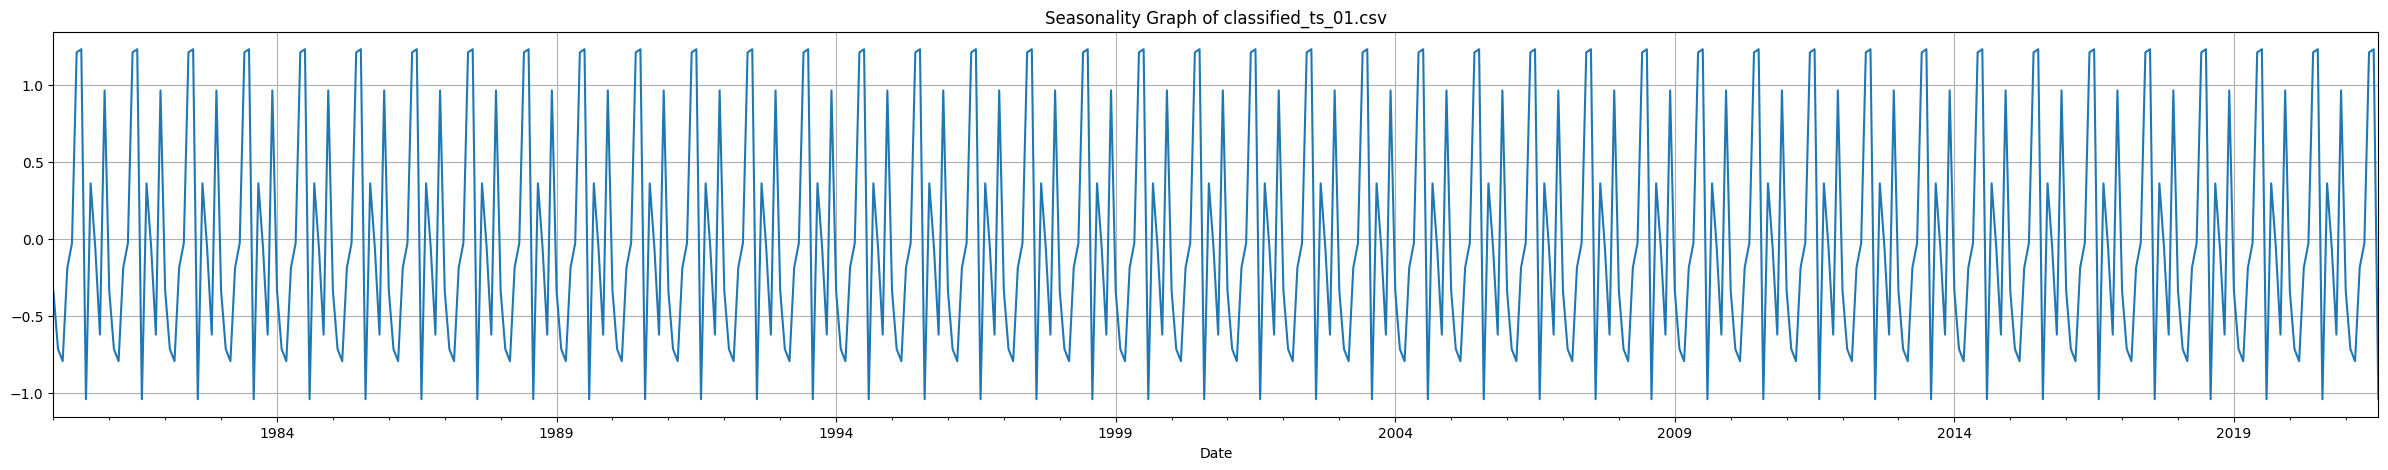

In [ ]:
# Question No. 2

ct1_decomp.seasonal.plot(figsize = (30,5))
plt.title('Seasonality Graph of classified_ts_01.csv')
plt.grid()
plt.show()

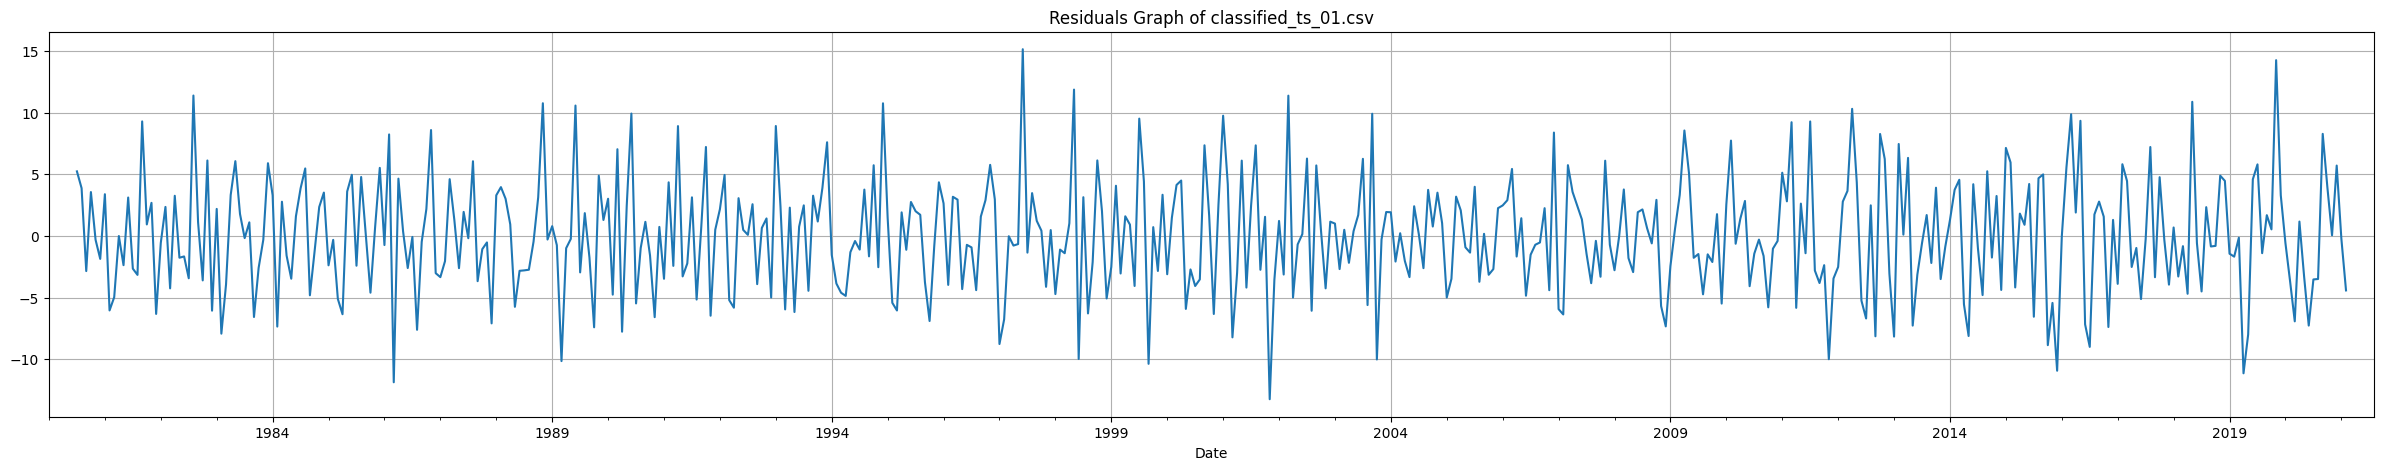

In [ ]:
# Question No. 3

ct1_decomp.resid.plot(figsize = (30,5))
plt.title('Residuals Graph of classified_ts_01.csv')
plt.grid()
plt.show()

In [ ]:
ct2['Date'] = pd.to_datetime(ct2['Date'])
ct2 = ct2.set_index('Date')
ct2_decomp = seasonal_decompose(ct2, model='additive')

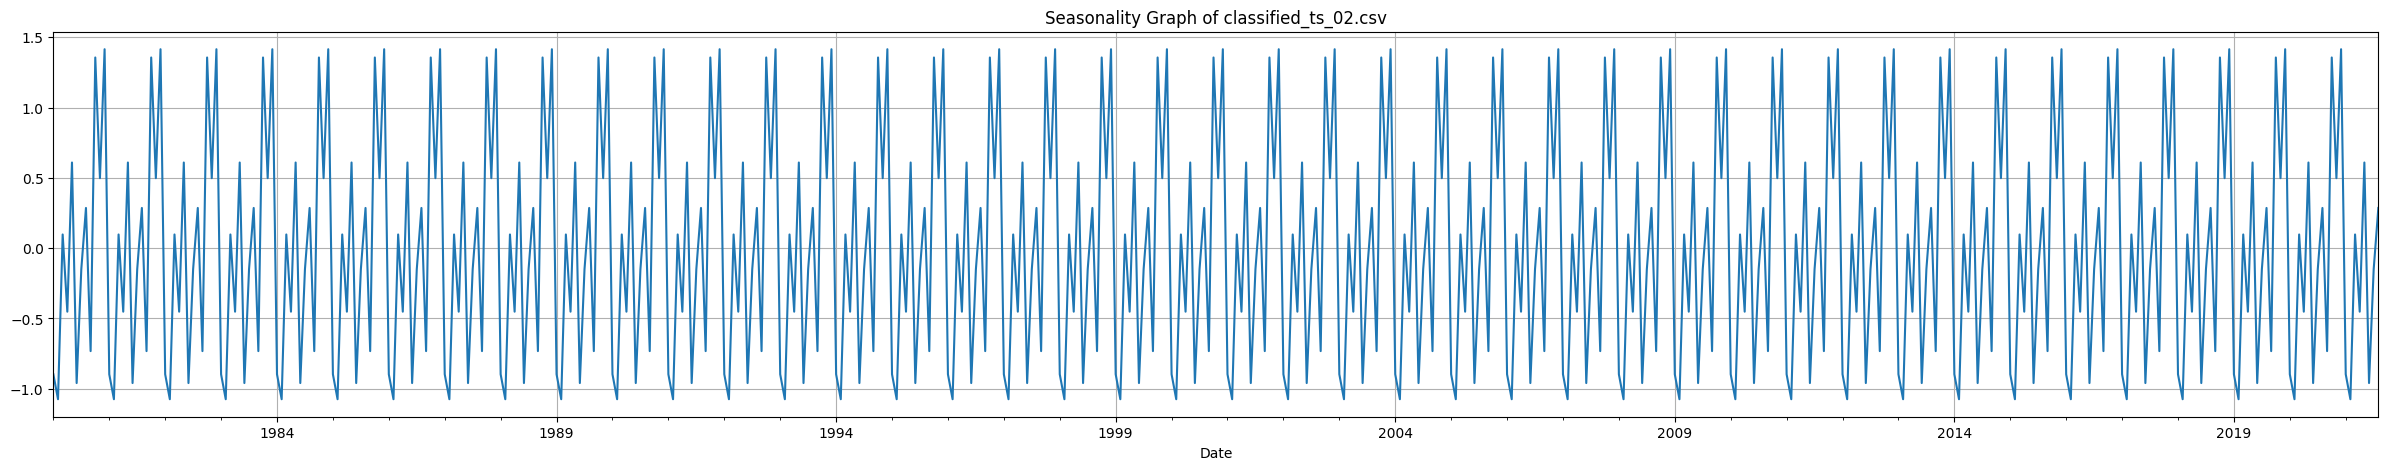

In [ ]:
# Question No. 4

ct2_decomp.seasonal.plot(figsize = (30,5))
plt.title('Seasonality Graph of classified_ts_02.csv')
plt.grid()
plt.show()

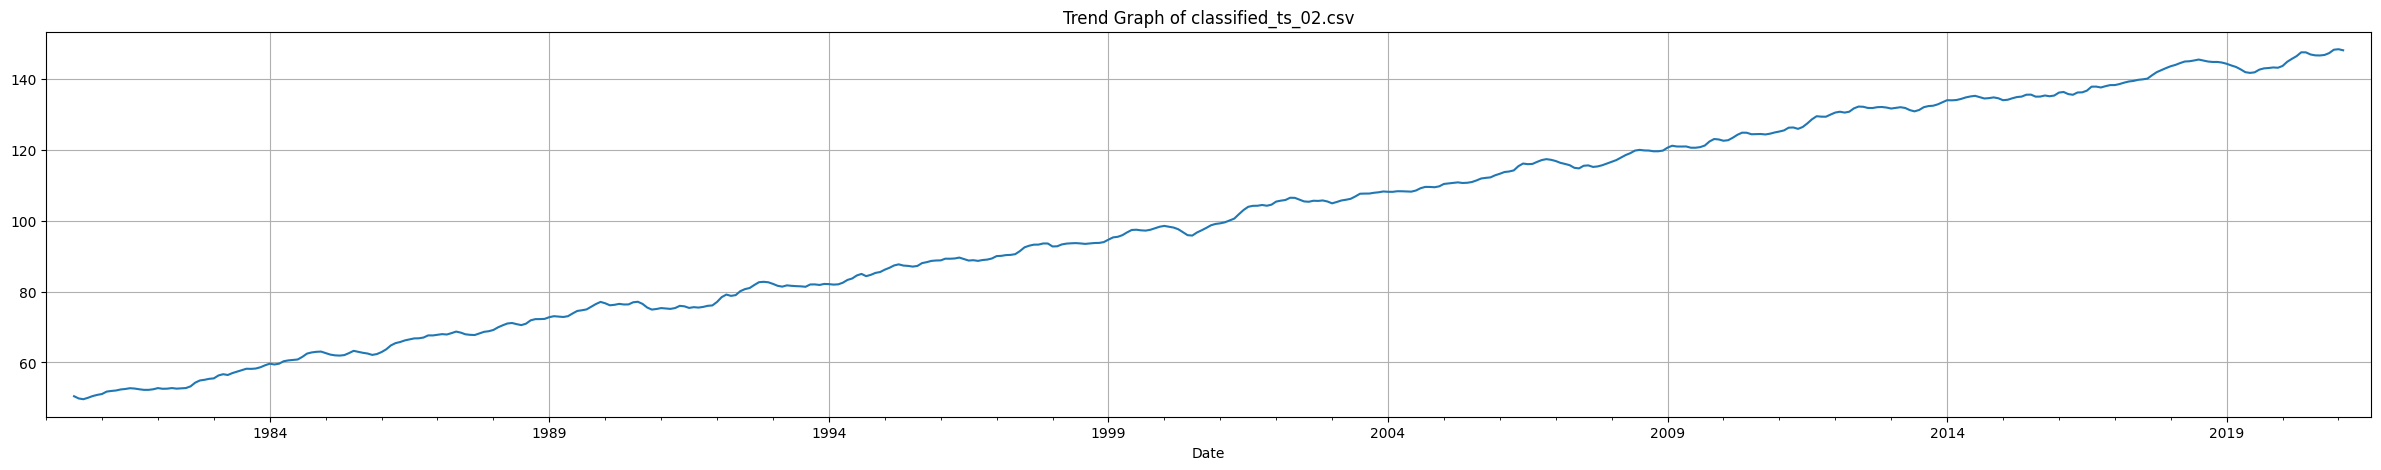

In [ ]:
# Question No. 5

ct2_decomp.trend.plot(figsize = (30,5))
plt.title('Trend Graph of classified_ts_02.csv')
plt.grid()
plt.show()

In [ ]:
from statsmodels.tsa.seasonal import STL

ct3['Date'] = pd.to_datetime(ct3['Date'])
ct3 = ct3.set_index('Date')
stl = STL(ct3, period = 12, robust = True)
decomp_stl = stl.fit()

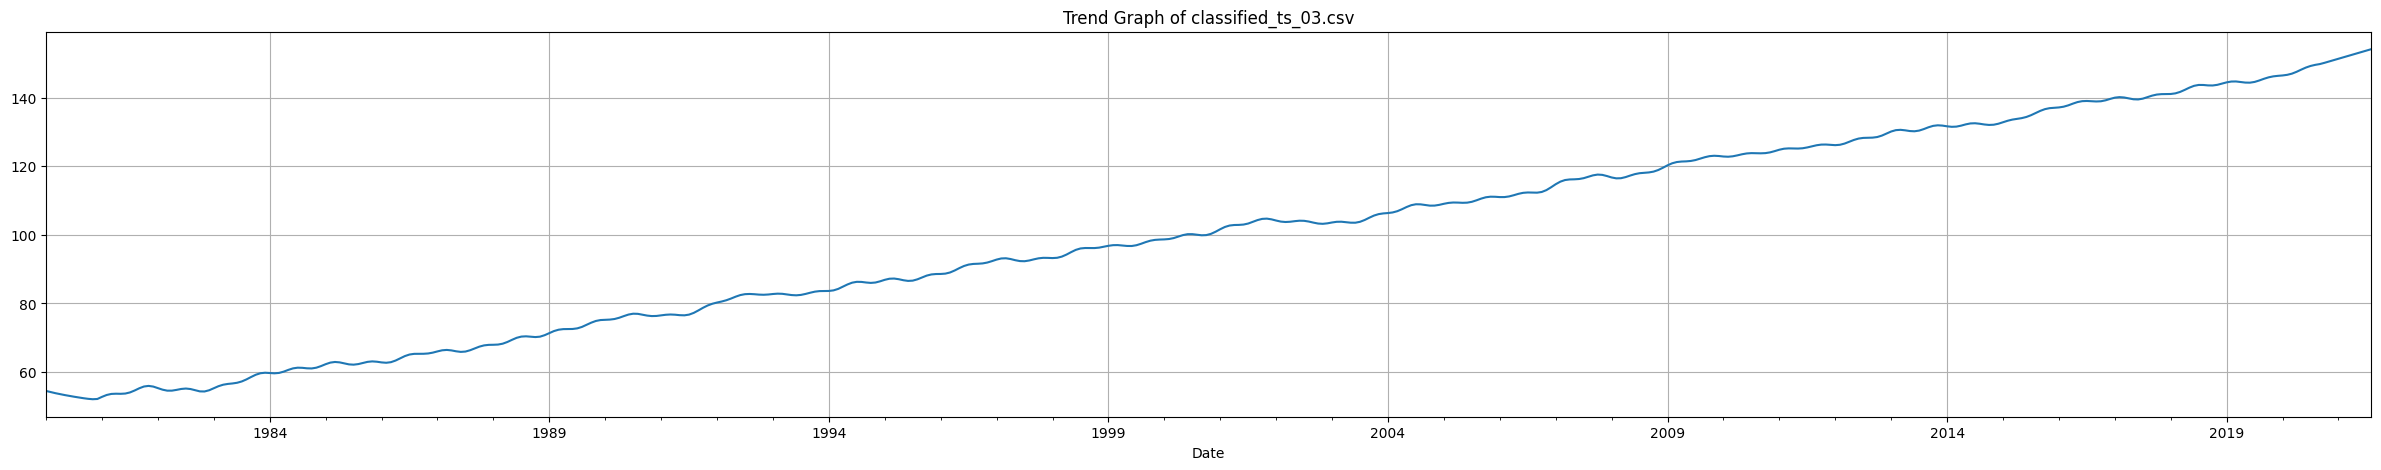

In [ ]:
# Question No. 6

decomp_stl.trend.plot(figsize = (30,5))
plt.title('Trend Graph of classified_ts_03.csv')
plt.grid()
plt.show()

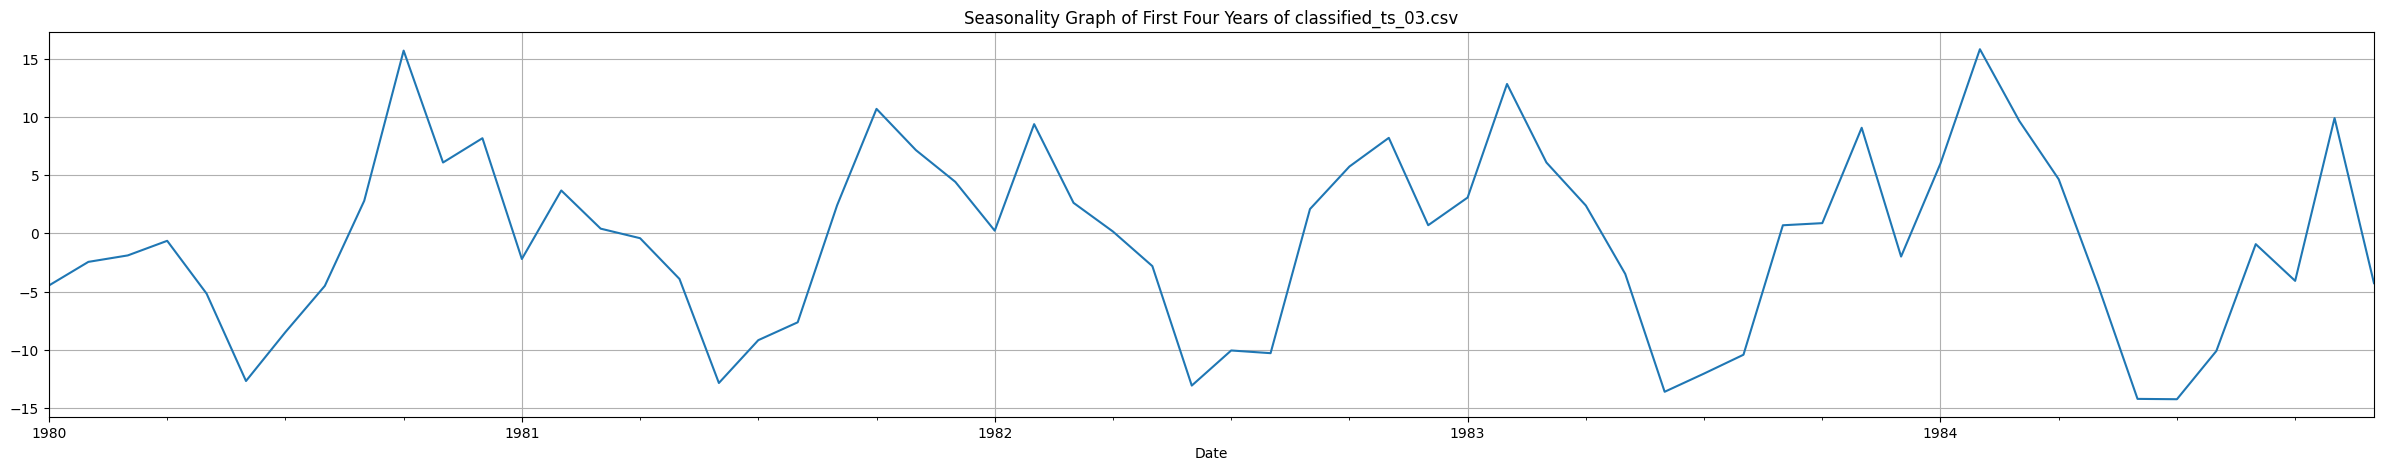

In [ ]:
# Question No. 7

ct3_f4 = ct3.loc['1980':'1984']
stl4 = STL(ct3_f4, period=12, robust=True)
f4 = stl4.fit()
f4.seasonal.plot(figsize = (30,5))
plt.title('Seasonality Graph of First Four Years of classified_ts_03.csv')
plt.grid()
plt.show()

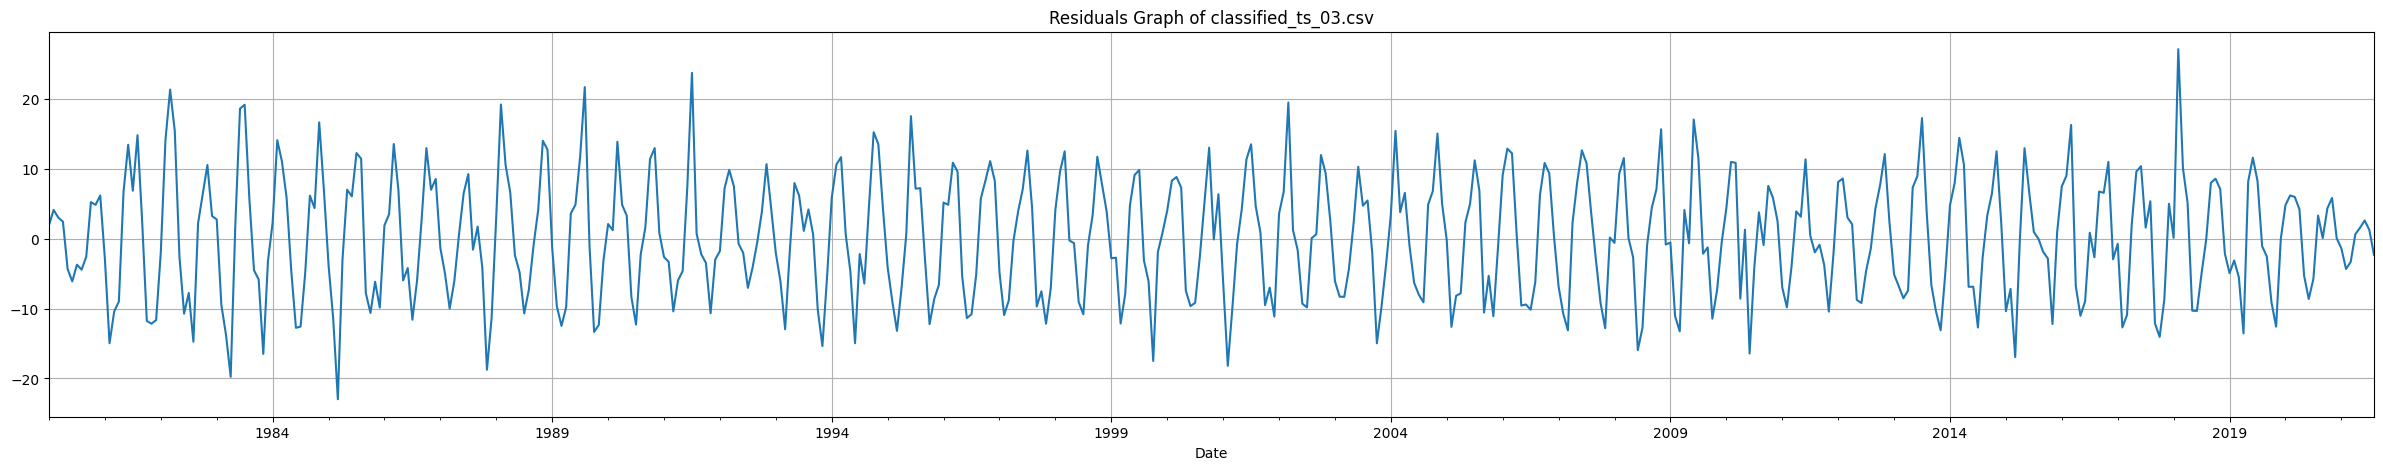

In [ ]:
# Question No. 8

decomp_stl.resid.plot(figsize = (30,5))
plt.title('Residuals Graph of classified_ts_03.csv')
plt.grid()
plt.show()

In [ ]:
ct4['Date'] = pd.to_datetime(ct4['Date'])
ct4 = ct4.set_index('Date')
stlc4 = STL(ct4, period = 12, robust = True)
decomp_stlc4 = stlc4.fit()

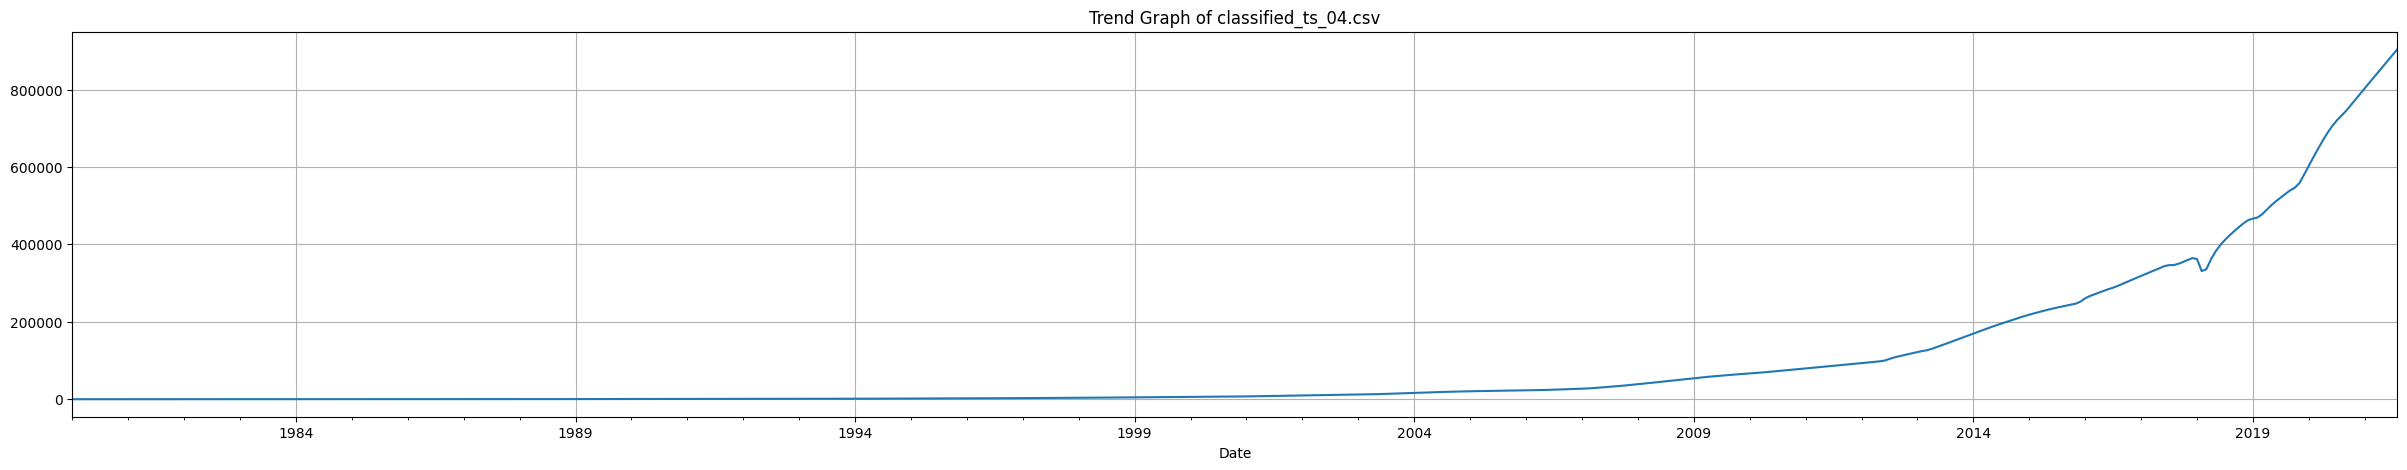

In [ ]:
# Question No. 9

decomp_stlc4.trend.plot(figsize = (30,5))
plt.title('Trend Graph of classified_ts_04.csv')
plt.grid()
plt.show()

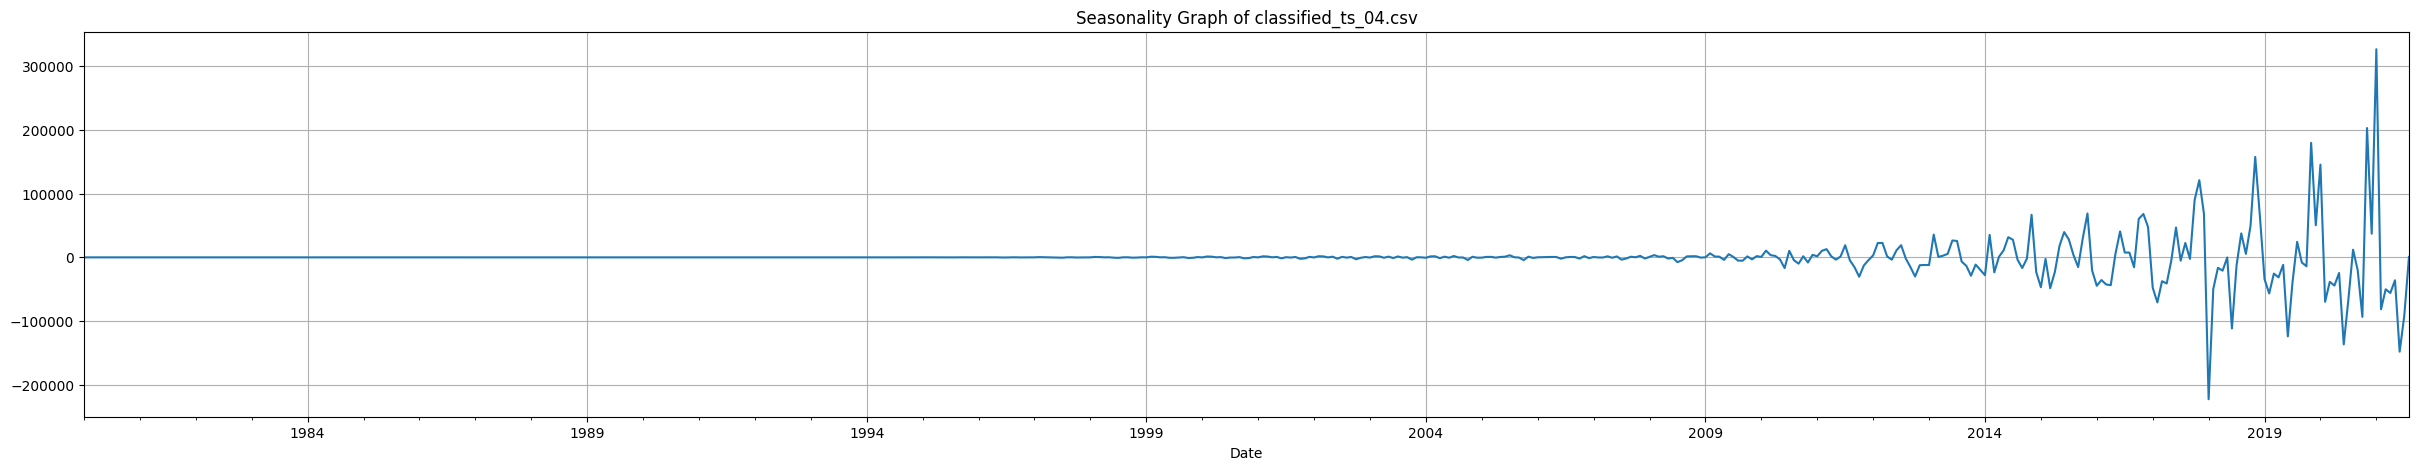

In [ ]:
# Question No. 10

decomp_stlc4.seasonal.plot(figsize = (30,5))
plt.title('Seasonality Graph of classified_ts_04.csv')
plt.grid()
plt.show()

In [ ]:
ct5['Date'] = pd.to_datetime(ct5['Date'])
ct5 = ct5.set_index('Date')
stlc5 = STL(ct5, period = 12, robust = True)
decomp_stlc5 = stlc5.fit()

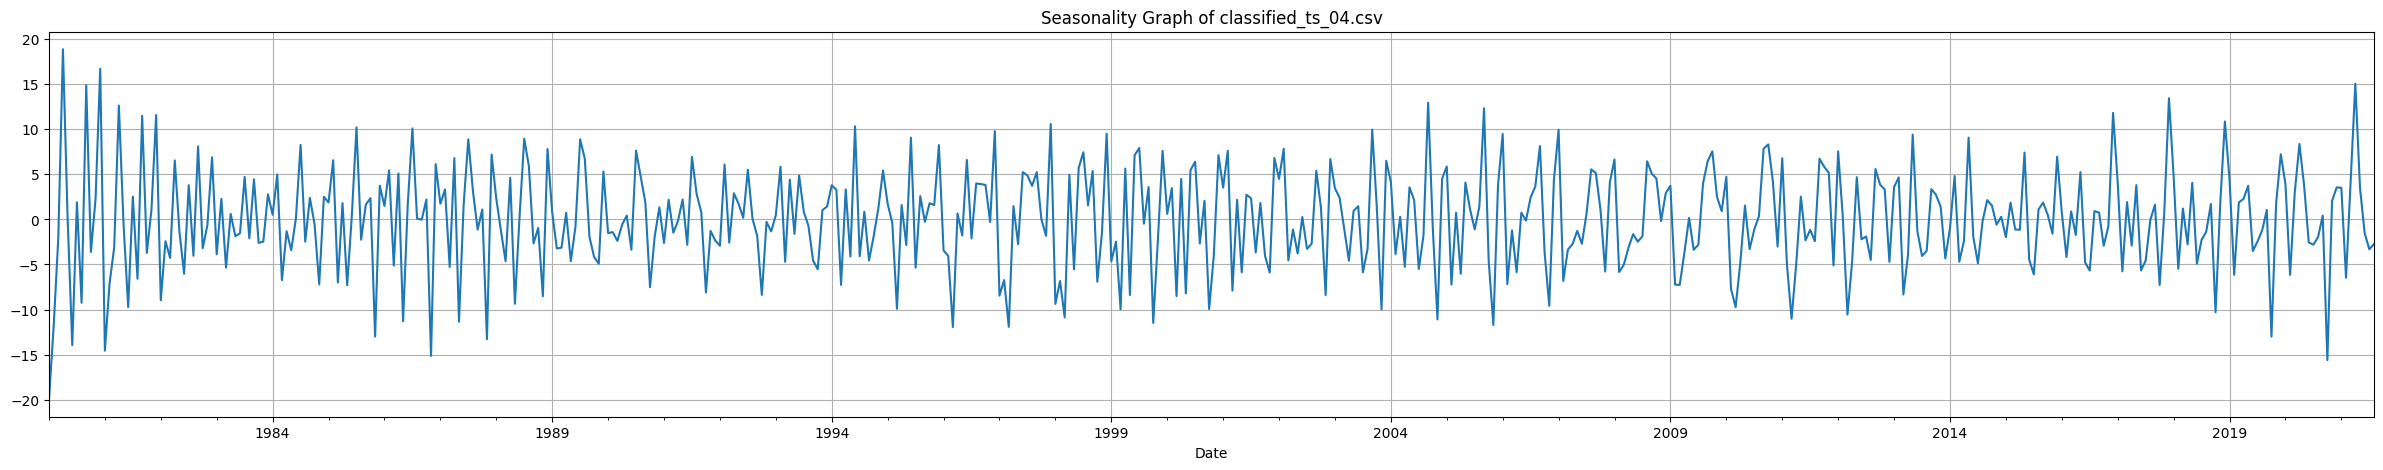

In [ ]:
# Question No. 11

decomp_stlc5.seasonal.plot(figsize = (30,5))
plt.title('Seasonality Graph of classified_ts_04.csv')
plt.grid()
plt.show()

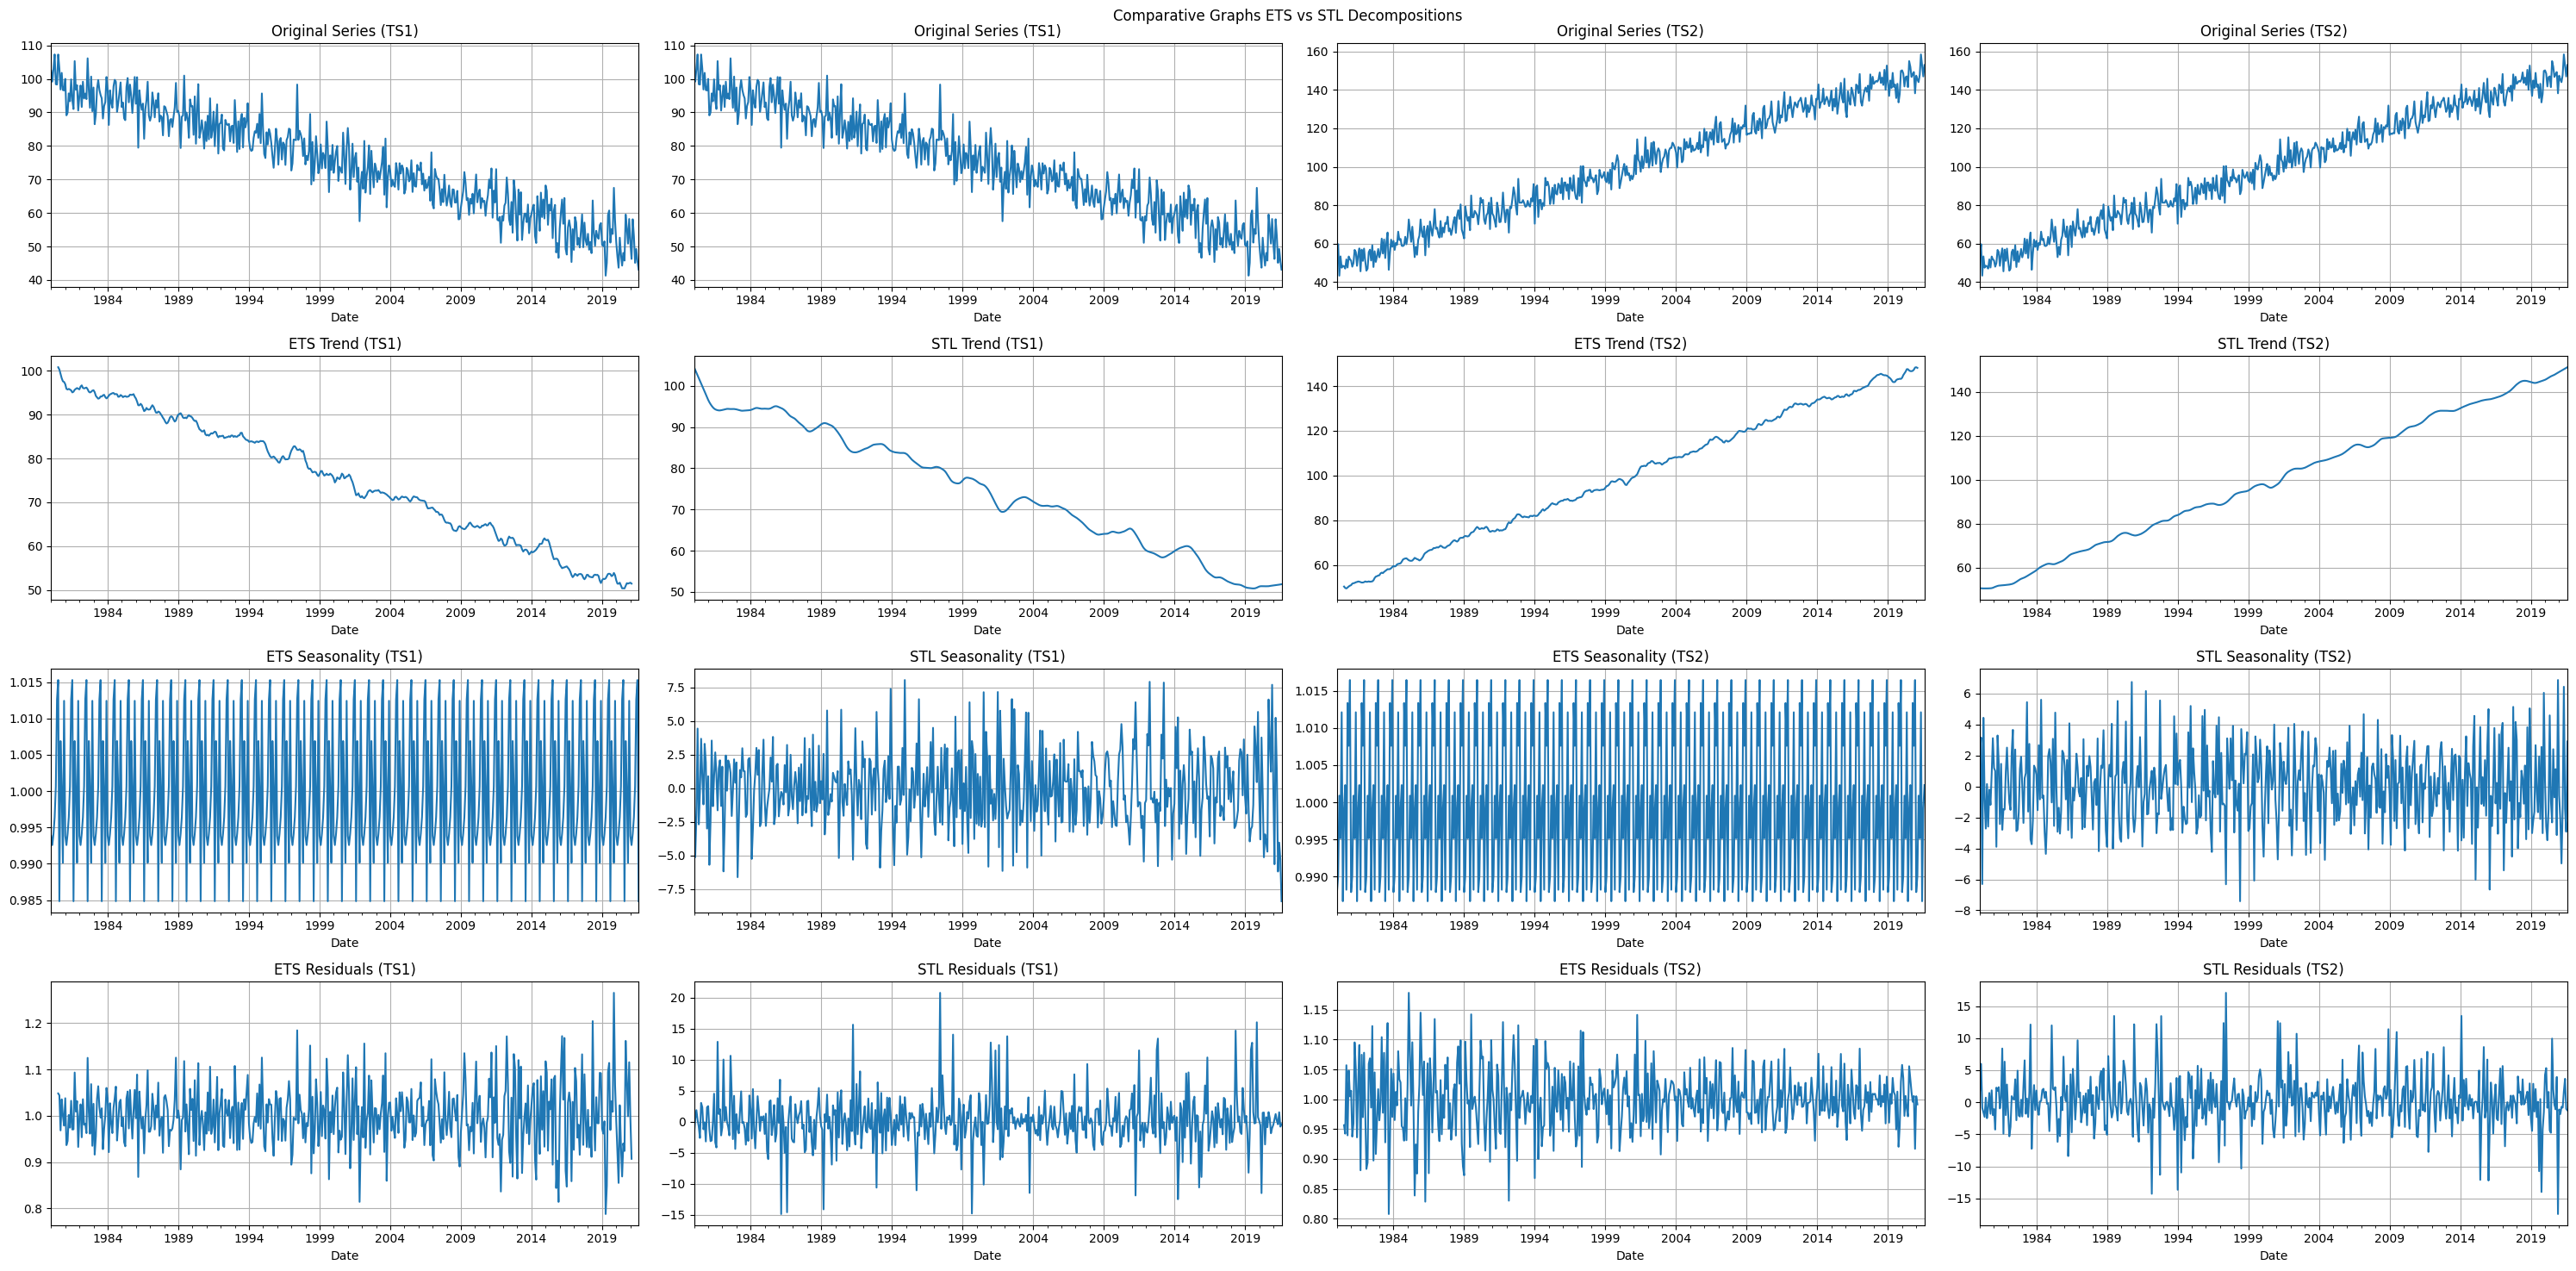

In [ ]:
# Question No. 12

# Side by Side Comparisons

ct1d = seasonal_decompose(ct1, model="multiplicative", period = 12)
stl1d = STL(ct1, period = 12, robust = True)
stl1decomp = stl1d.fit()
ct2d = seasonal_decompose(ct2, model="multiplicative", period = 12)
stl2d = STL(ct2, period = 12, robust = True)
stl2decomp = stl2d.fit()

# Plot ETS and STL Decomposition Side-by-Side
fig, axes = plt.subplots(4, 4, figsize=(30, 15))
fig.suptitle("Comparative Graphs ETS vs STL Decompositions")

# Titles for both models
titles1E = ["Original Series (TS1)", "ETS Trend (TS1)", "ETS Seasonality (TS1)", "ETS Residuals (TS1)"]
titles1S = ["Original Series (TS1)", "STL Trend (TS1)", "STL Seasonality (TS1)", "STL Residuals (TS1)"]
titles2E = ["Original Series (TS2)", "ETS Trend (TS2)", "ETS Seasonality (TS2)", "ETS Residuals (TS2)"]
titles2S = ["Original Series (TS2)", "STL Trend (TS2)", "STL Seasonality (TS2)", "STL Residuals (TS2)"]

# Plot ETS Decomposition (Left/Side)
components_ets1 = [ct1, ct1d.trend, ct1d.seasonal, ct1d.resid]
for i, component in enumerate(components_ets1):

    component.plot(ax = axes[i, 0], title = titles1E[i], legend=False)
    axes[i, 0].grid()

# Plot STL Decomposition (Left-Mid/Side)
components_stl1 = [ct1, stl1decomp.trend, stl1decomp.seasonal, stl1decomp.resid]
for i, component in enumerate(components_stl1):

    component.plot(ax = axes[i, 1], title = titles1S[i], legend=False)
    axes[i, 1].grid()

# Plot ETS Decomposition (Right-Mid/Side)
components_ets2 = [ct2, ct2d.trend, ct2d.seasonal, ct2d.resid]
for i, component in enumerate(components_ets2):

    component.plot(ax = axes[i, 2], title = titles2E[i], legend=False)
    axes[i, 2].grid()

# Plot STL Decomposition (Right/Side)
components_stl2 = [ct2, stl2decomp.trend, stl2decomp.seasonal, stl2decomp.resid]
for i, component in enumerate(components_stl2):

    component.plot(ax = axes[i, 3], title = titles2S[i], legend=False)
    axes[i, 3].grid()

plt.tight_layout()
plt.show()

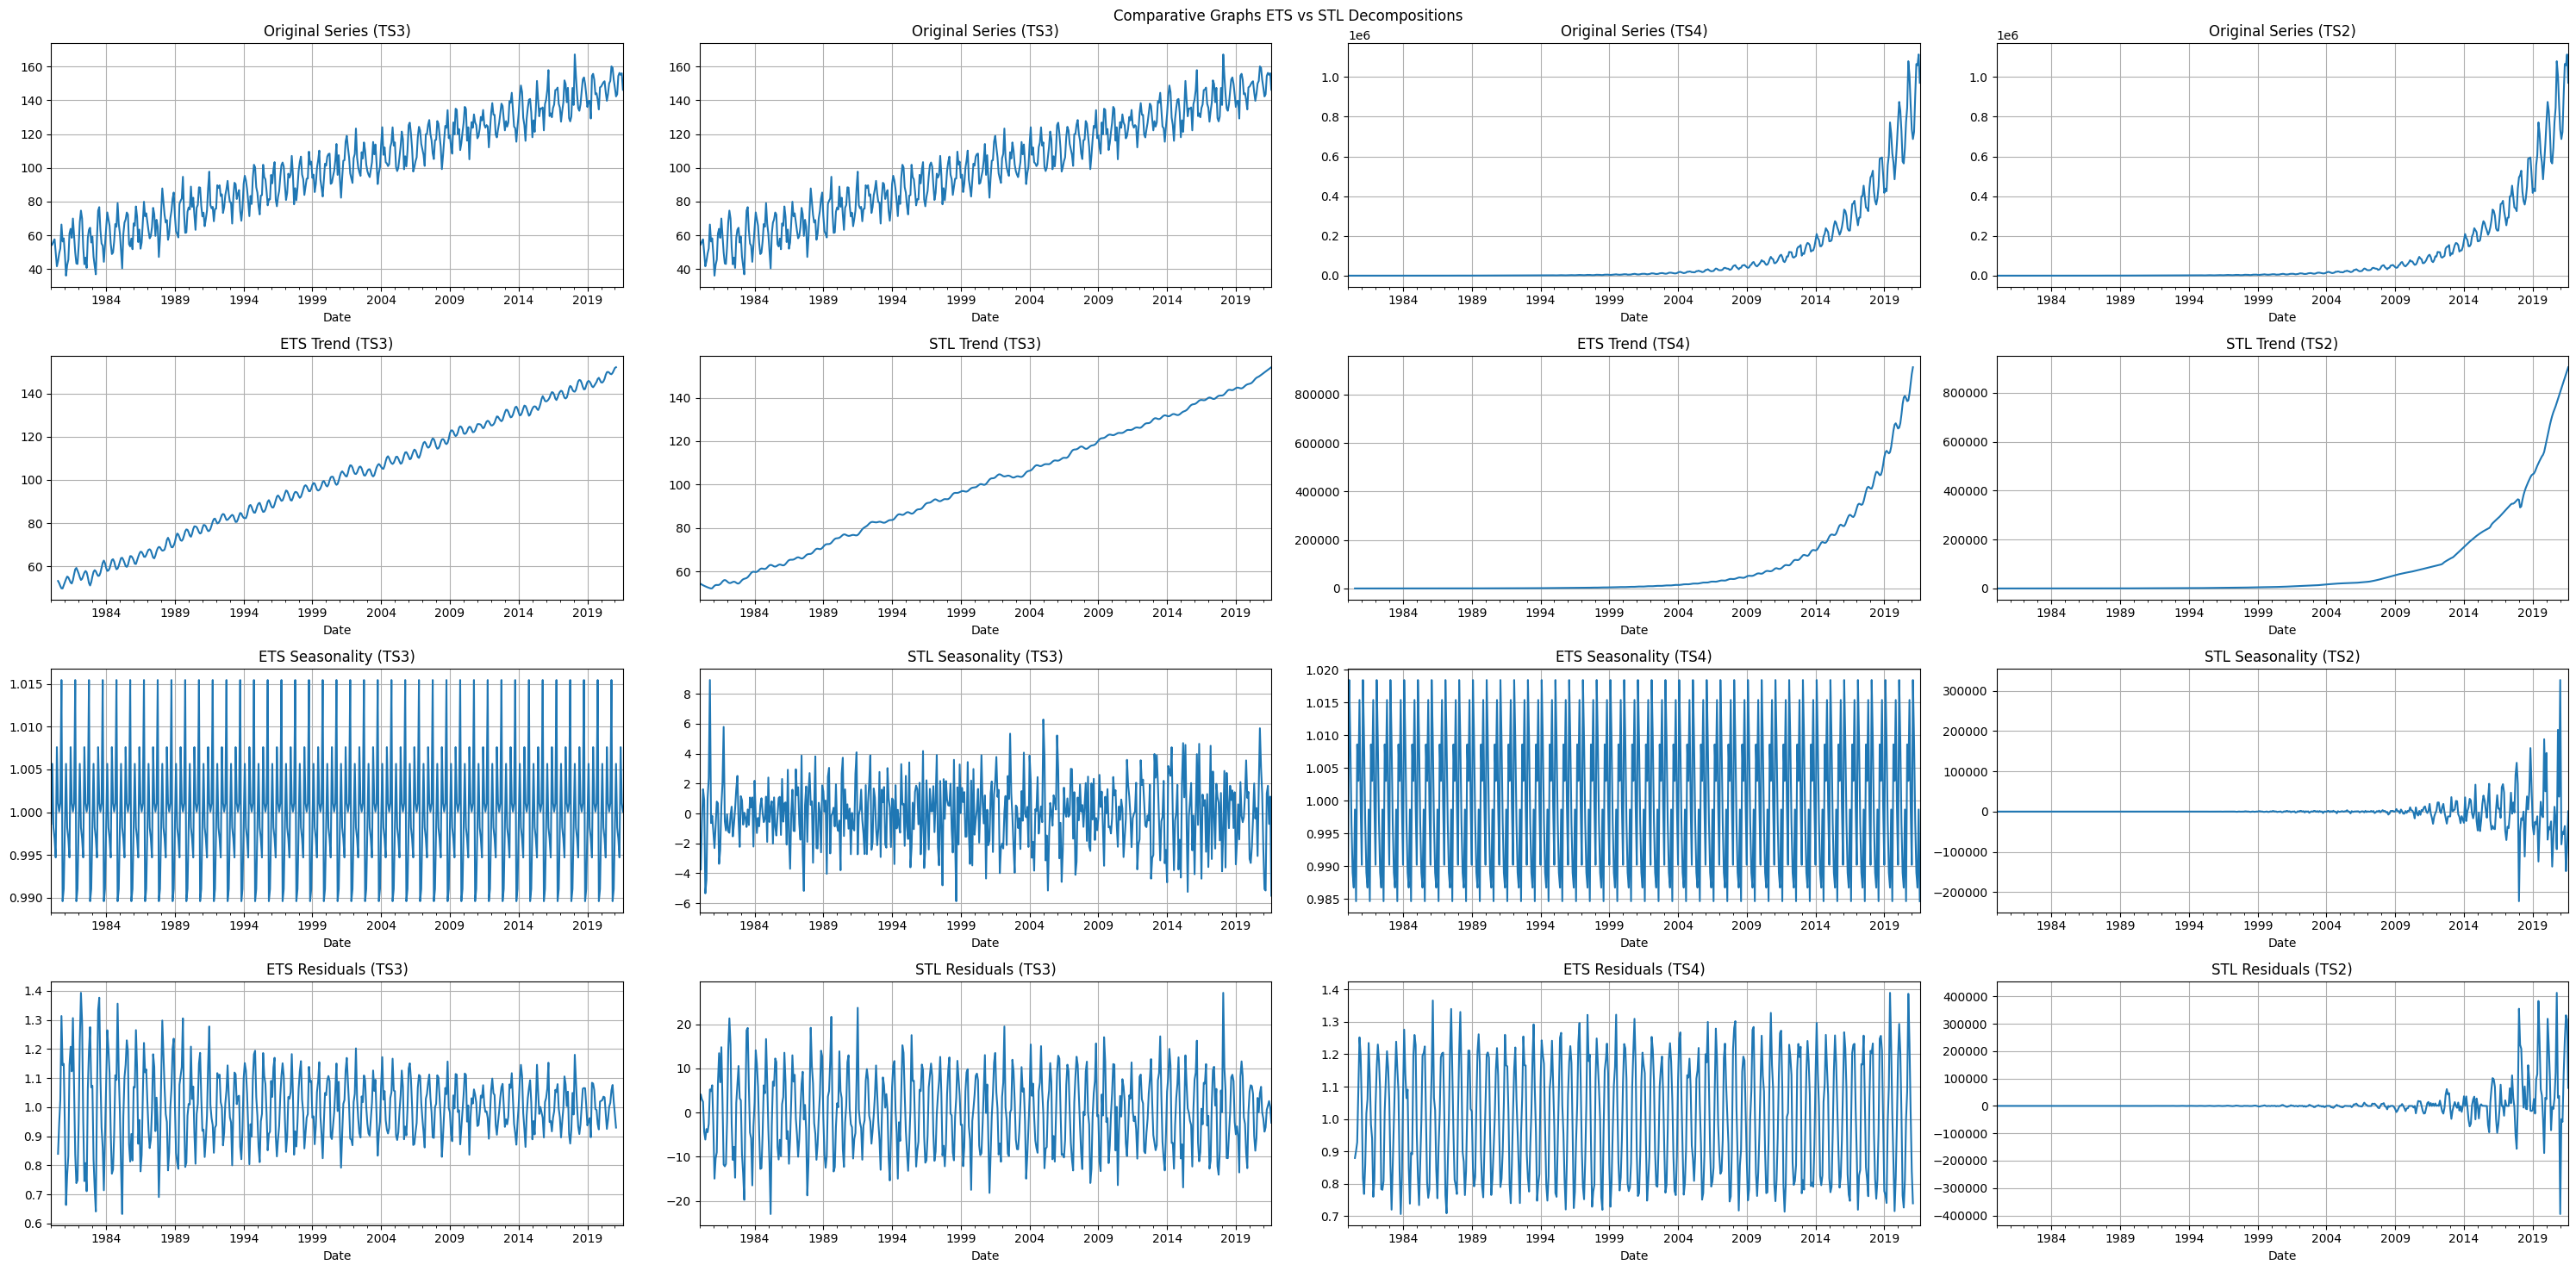

In [ ]:
# Question No. 13

# Side by Side Comparisons

ct3d = seasonal_decompose(ct3, model="multiplicative", period = 12)
stl3d = STL(ct3, period = 12, robust = True)
stl3decomp = stl3d.fit()
ct4d = seasonal_decompose(ct4, model="multiplicative", period = 12)
stl4d = STL(ct4, period = 12, robust = True)
stl4decomp = stl4d.fit()

# Plot ETS and STL Decomposition Side-by-Side
fig, axes = plt.subplots(4, 4, figsize=(30, 15))
fig.suptitle("Comparative Graphs ETS vs STL Decompositions")

# Titles for both models
titles3E = ["Original Series (TS3)", "ETS Trend (TS3)", "ETS Seasonality (TS3)", "ETS Residuals (TS3)"]
titles3S = ["Original Series (TS3)", "STL Trend (TS3)", "STL Seasonality (TS3)", "STL Residuals (TS3)"]
titles4E = ["Original Series (TS4)", "ETS Trend (TS4)", "ETS Seasonality (TS4)", "ETS Residuals (TS4)"]
titles4S = ["Original Series (TS4)", "STL Trend (TS4)", "STL Seasonality (TS4)", "STL Residuals (TS4)"]

# Plot ETS Decomposition (Left/Side)
components_ets3 = [ct3, ct3d.trend, ct3d.seasonal, ct3d.resid]
for i, component in enumerate(components_ets3):

    component.plot(ax = axes[i, 0], title = titles3E[i], legend=False)
    axes[i, 0].grid()

# Plot STL Decomposition (Left-Mid/Side)
components_stl3 = [ct3, stl3decomp.trend, stl3decomp.seasonal, stl3decomp.resid]
for i, component in enumerate(components_stl3):

    component.plot(ax = axes[i, 1], title = titles3S[i], legend=False)
    axes[i, 1].grid()

# Plot ETS Decomposition (Right-Mid/Side)
components_ets4 = [ct4, ct4d.trend, ct4d.seasonal, ct4d.resid]
for i, component in enumerate(components_ets4):

    component.plot(ax = axes[i, 2], title = titles4E[i], legend=False)
    axes[i, 2].grid()

# Plot STL Decomposition (Right/Side)
components_stl4 = [ct4, stl4decomp.trend, stl4decomp.seasonal, stl4decomp.resid]
for i, component in enumerate(components_stl4):

    component.plot(ax = axes[i, 3], title = titles2S[i], legend=False)
    axes[i, 3].grid()

plt.tight_layout()
plt.show()